# 6 · The Evolved Quantum Boltzmann Machine

The **Evolved QBM** (EQBM, arXiv:2501.03367) wraps the Gibbs state in a real-time
unitary evolution under a second Hamiltonian:

$$\omega(\theta,\phi) = e^{-iH(\phi)}\, \rho(\theta)\, e^{+iH(\phi)},
\qquad \rho(\theta) = \frac{e^{-G(\theta)}}{Z}, \qquad H(\phi) = \sum_k \phi_k H_k .$$

The plain QBM is the special case $\phi = 0$. The extra real-time parameters make
the model strictly more expressive — it can reach states that are *not* Gibbs
states of any $G$ in the chosen family.

**Why it costs us almost nothing to support.** $\omega = U\rho U^\dagger$ is just
$\rho$ conjugated by a unitary $U=e^{-iH(\phi)}$. So $\omega$ has the same
eigenvalues as $\rho$, its $\theta$-derivatives are $U(\partial_\theta\rho)U^\dagger$,
and its $\phi$-derivatives come from the Daleckii–Krein kernel for $\partial U$.
Exposing $\{\partial_i\omega\}$ and $\omega$'s spectrum makes the existing
`Energy` / `MarginalRelativeEntropy` losses and all three QFI metrics work on the
EQBM unchanged.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm.losses import Energy, MarginalRelativeEntropy
from qbm.operators import local_pauli_generators, ParamHamiltonian

n = 3
G = local_pauli_generators(n)                 # imaginary-time generators (Z, X, ZZ)
Hgen = ["XII", "IXI", "IIX"]                   # real-time generators (X fields)
model = qbm.EvolvedQBM(G, Hgen)
print(model, "| n_theta =", model.n_theta, " n_phi =", model.n_phi)

EvolvedQBM(n_qubits=3, n_theta=8, n_phi=3) | n_theta = 8  n_phi = 3


### Sanity check: at $\phi = 0$ the EQBM is exactly a QBM

In [2]:
rng = np.random.default_rng(1)
theta = rng.normal(scale=0.5, size=len(G))
m0 = qbm.EvolvedQBM(G, Hgen, theta=theta, phi=np.zeros(len(Hgen)))
rho = qbm.DenseBackend().thermal_state(ParamHamiltonian(G), theta).density_matrix()
print("max |omega(phi=0) - rho| =", np.max(np.abs(m0.density_matrix() - rho)))

max |omega(phi=0) - rho| = 0.0


### Ground-state energy with the EQBM

We minimise $\mathrm{Tr}[H\,\omega]$ with quantum natural gradient. The gradient
spans both $\theta$ and $\phi$; `qbmkit` returns the concatenated vector and the
training loop is identical to the plain QBM.

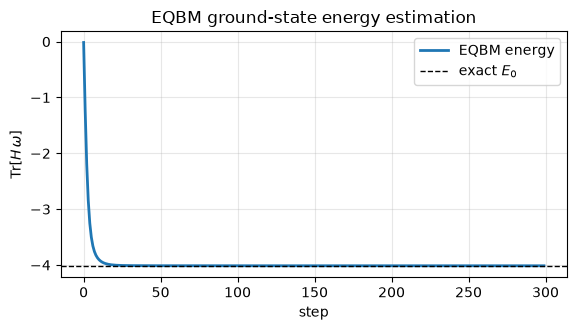

EQBM energy = -4.01396  exact = -4.01404


In [3]:
H = qbm.hamiltonians.tfim(n, J=1.0, g=1.2)
e0 = qbm.oracles.ground_energy(H)
model.theta = np.concatenate([rng.normal(scale=0.05, size=model.n_theta), np.zeros(model.n_phi)])
hist = qbm.fit(model, Energy(H),
               qbm.optim.NaturalGradient(metric="kubo_mori", lr=0.2, reg=1e-3), steps=300)

plt.figure(figsize=(6, 3.4))
plt.plot(hist.loss, lw=2, label="EQBM energy")
plt.axhline(e0, ls="--", color="k", lw=1, label="exact $E_0$")
plt.xlabel("step"); plt.ylabel(r"$\mathrm{Tr}[H\,\omega]$"); plt.legend(); plt.grid(alpha=0.3)
plt.title("EQBM ground-state energy estimation"); plt.tight_layout(); plt.show()
print("EQBM energy =", round(model.energy(H), 5), " exact =", round(e0, 5))

### The extra expressivity of real-time evolution

We build a target that is itself an *evolved* Gibbs state $\omega_\star$. A plain
QBM (same $G$) can only produce Gibbs states and cannot represent $\omega_\star$,
so its relative entropy hits a floor — while the EQBM drives it to zero.

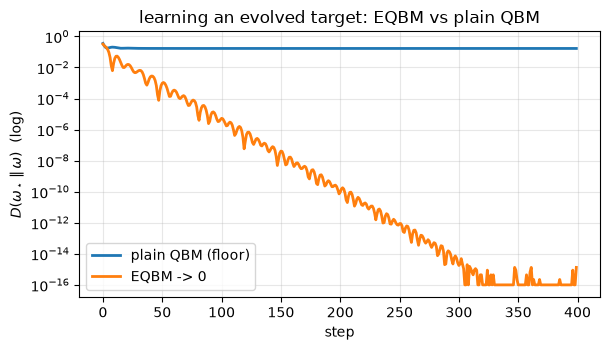

plain QBM final D = 1.675e-01  | EQBM final D = 1.332e-15


In [4]:
# realizable evolved target
src = qbm.EvolvedQBM(G, Hgen)
src.theta = np.concatenate([rng.normal(scale=0.5, size=src.n_theta),
                            rng.normal(scale=0.6, size=src.n_phi)])
omega_star = src.density_matrix()

# (a) plain QBM with the same G generators
qbm_plain = qbm.FullyVisibleQBM(generators=G)
qbm_plain.theta = rng.normal(scale=0.1, size=qbm_plain.n_params)
h_plain = qbm.fit(qbm_plain, MarginalRelativeEntropy(omega_star, n_visible=n),
                  qbm.optim.Adam(lr=0.1), steps=400)

# (b) EQBM (theta + phi)
eqbm = qbm.EvolvedQBM(G, Hgen)
eqbm.theta = np.concatenate([rng.normal(scale=0.1, size=eqbm.n_theta),
                             rng.normal(scale=0.1, size=eqbm.n_phi)])
h_eqbm = qbm.fit(eqbm, MarginalRelativeEntropy(omega_star, n_visible=n),
                 qbm.optim.Adam(lr=0.1), steps=400)

plt.figure(figsize=(6.2, 3.6))
plt.semilogy(np.clip(h_plain.loss, 1e-16, None), lw=2, label="plain QBM (floor)")
plt.semilogy(np.clip(h_eqbm.loss, 1e-16, None), lw=2, label="EQBM -> 0")
plt.xlabel("step"); plt.ylabel(r"$D(\omega_\star\,\|\,\omega)$  (log)")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("learning an evolved target: EQBM vs plain QBM"); plt.tight_layout(); plt.show()
print("plain QBM final D =", f"{h_plain.final_loss:.3e}", " | EQBM final D =", f"{h_eqbm.final_loss:.3e}")

### The EQBM information metric

The quantum Fisher information now has $\theta$, $\phi$, and cross $\theta$–$\phi$
blocks. `qbmkit` computes all three QFI variants from the same monotone-metric
formula applied to $\{\partial_i\omega\}$ — no special-case code.

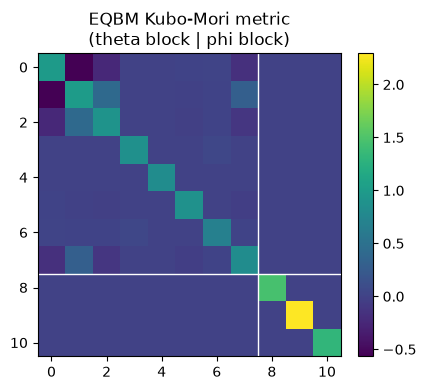

metric shape: (11, 11) (theta: 8 , phi: 3 )


In [5]:
g = eqbm.state().metric("kubo_mori")
nt = eqbm.n_theta
plt.figure(figsize=(4.4, 4))
im = plt.imshow(g, cmap="viridis")
plt.axhline(nt - 0.5, color="w", lw=1); plt.axvline(nt - 0.5, color="w", lw=1)
plt.title("EQBM Kubo-Mori metric\n(theta block | phi block)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print("metric shape:", g.shape, "(theta:", nt, ", phi:", eqbm.n_phi, ")")

### Recap

- The EQBM adds real-time evolution on top of the Gibbs state, increasing
  expressivity at essentially no implementation cost — it reuses the whole stack.
- It still estimates ground-state energies, and it can learn targets a plain QBM
  cannot represent.
- Its quantum Fisher information (all three variants) comes from the same unified
  metric machinery, including the theta–phi cross terms.